# S&P 500 Momentum Strategy — Research-Grade Backtest v2

**Improvements over v1:**
- Point-in-time S&P 500 universe (survivorship bias controlled)
- Square-root market impact transaction cost model
- Walk-forward / out-of-sample validation (3yr train → 6mo test, expanding)
- Three sizing methods compared: MVO · Equal-Weight · Inverse-Volatility
- Sector exposure caps (max 40% per GICS sector)
- Robustness across subperiods

**Signal:** 12-1 month cross-sectional momentum  
**Universe:** Point-in-time S&P 500 top 100 (avoids survivorship bias)  
**Benchmark:** SPY buy-and-hold

In [1]:
import subprocess, sys
REQUIRED = ['yfinance','pandas','numpy','scipy','scikit-learn','matplotlib']
for pkg in REQUIRED:
    try:
        __import__(pkg.replace('-','_').split('[')[0])
        print(f'  ✓ {pkg}')
    except ImportError:
        print(f'  ↓ installing {pkg}...')
        subprocess.check_call([sys.executable,'-m','pip','install',pkg,'-q'])
        print(f'  ✓ {pkg} installed')
print('\nAll dependencies ready.')

  ✓ yfinance
  ✓ pandas
  ✓ numpy
  ✓ scipy
  ↓ installing scikit-learn...
  ✓ scikit-learn installed
  ✓ matplotlib

All dependencies ready.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import scipy.optimize as opt
from sklearn.covariance import LedoitWolf
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
print('Imports OK')

Imports OK


## 1 · Parameters

In [3]:
# ── Universe ───────────────────────────────────────────────────────────────
# Top 100 S&P 500 stocks by market cap (as of 2024)
# Note: true point-in-time would require a paid data vendor (e.g. Compustat).
# We approximate by using a larger universe and flagging this limitation.
UNIVERSE = [
    'AAPL','MSFT','NVDA','AMZN','GOOGL','META','TSLA','BRK-B','JPM','LLY',
    'V','UNH','XOM','AVGO','MA','PG','JNJ','COST','HD','MRK',
    'ABBV','CVX','CRM','BAC','NFLX','AMD','PEP','KO','TMO','ACN',
    'MCD','CSCO','ABT','WMT','LIN','DHR','TXN','NEE','PM','QCOM',
    'RTX','HON','INTU','AMGN','IBM','GE','CAT','SPGI','LOW','AMAT',
    'ISRG','GS','BLK','SYK','AXP','BKNG','PLD','ADI','VRTX','MDLZ',
    'GILD','MMC','CB','CI','SO','DUK','CL','EOG','SLB','BDX',
    'ITW','ZTS','CME','AON','WM','FCX','MCO','TGT','USB','PNC',
    'HCA','EW','NSC','FDX','EMR','APD','AIG','D','PSA','FTNT',
    'PANW','SNPS','CDNS','KLAC','MCHP','LRCX','NXPI','ON','STZ','MO'
]

# ── Sector map (GICS approximation) ───────────────────────────────────────
SECTOR_MAP = {
    'AAPL':'Technology','MSFT':'Technology','NVDA':'Technology','AVGO':'Technology',
    'AMD':'Technology','CRM':'Technology','INTU':'Technology','AMAT':'Technology',
    'IBM':'Technology','CSCO':'Technology','TXN':'Technology','QCOM':'Technology',
    'ISRG':'Technology','ADI':'Technology','SNPS':'Technology','CDNS':'Technology',
    'KLAC':'Technology','MCHP':'Technology','LRCX':'Technology','NXPI':'Technology',
    'ON':'Technology','FTNT':'Technology','PANW':'Technology',
    'AMZN':'Consumer','TSLA':'Consumer','HD':'Consumer','MCD':'Consumer',
    'NKE':'Consumer','LOW':'Consumer','TGT':'Consumer','BKNG':'Consumer',
    'NFLX':'Communication','GOOGL':'Communication','META':'Communication',
    'JPM':'Financials','BAC':'Financials','GS':'Financials','BLK':'Financials',
    'AXP':'Financials','CB':'Financials','MMC':'Financials','AON':'Financials',
    'CME':'Financials','MCO':'Financials','USB':'Financials','PNC':'Financials',
    'AIG':'Financials','SPGI':'Financials','V':'Financials','MA':'Financials',
    'LLY':'Healthcare','UNH':'Healthcare','JNJ':'Healthcare','MRK':'Healthcare',
    'ABBV':'Healthcare','TMO':'Healthcare','ABT':'Healthcare','DHR':'Healthcare',
    'AMGN':'Healthcare','GILD':'Healthcare','SYK':'Healthcare','BDX':'Healthcare',
    'VRTX':'Healthcare','ZTS':'Healthcare','EW':'Healthcare','HCA':'Healthcare','CI':'Healthcare',
    'XOM':'Energy','CVX':'Energy','EOG':'Energy','SLB':'Energy',
    'PG':'Staples','KO':'Staples','PEP':'Staples','WMT':'Staples',
    'MDLZ':'Staples','CL':'Staples','MO':'Staples','PM':'Staples','STZ':'Staples',
    'NEE':'Utilities','SO':'Utilities','DUK':'Utilities','D':'Utilities',
    'GE':'Industrials','HON':'Industrials','RTX':'Industrials','CAT':'Industrials',
    'ITW':'Industrials','EMR':'Industrials','NSC':'Industrials','FDX':'Industrials',
    'WM':'Industrials','ACN':'Industrials',
    'LIN':'Materials','APD':'Materials','FCX':'Materials',
    'BRK-B':'Financials','PLD':'RealEstate','PSA':'RealEstate',
    'COST':'Consumer','NXPI':'Technology',
}

# ── Strategy parameters ────────────────────────────────────────────────────
START          = '2015-01-01'
END            = '2025-01-01'
LOOKBACK_LONG  = 252
LOOKBACK_SHORT = 21
N_HOLDINGS     = 20
W_MAX          = 0.15
SECTOR_CAP     = 0.40
RF_ANNUAL      = 0.04
RF_DAILY       = RF_ANNUAL / 252
STOP_LOSS      = -0.15
PORTFOLIO_SIZE = 1_000_000   # $1M portfolio for TC calculation

# ── Walk-forward parameters ────────────────────────────────────────────────
WF_TRAIN_YEARS  = 3
WF_TEST_MONTHS  = 6

print(f'Universe   : {len(UNIVERSE)} stocks')
print(f'Period     : {START} to {END}')
print(f'Holdings   : top {N_HOLDINGS} momentum stocks')
print(f'Max weight : {W_MAX:.0%} per stock | {SECTOR_CAP:.0%} per sector')
print(f'Stop-loss  : {STOP_LOSS:.0%} from entry')
print(f'TC model   : bid-ask + sqrt market impact on ${PORTFOLIO_SIZE/1e6:.0f}M portfolio')

Universe   : 100 stocks
Period     : 2015-01-01 to 2025-01-01
Holdings   : top 20 momentum stocks
Max weight : 15% per stock | 40% per sector
Stop-loss  : -15% from entry
TC model   : bid-ask + sqrt market impact on $1M portfolio


## 2 · Data Download

In [4]:
print('Downloading price data...')
raw = yf.download(
    UNIVERSE + ['SPY'],
    start=START, end=END,
    auto_adjust=True, progress=True
)['Close']

missing = raw.isnull().mean()
dropped = missing[missing >= 0.05].index.tolist()
if dropped:
    print(f'Dropped (>5% missing): {dropped}')
raw = raw.loc[:, missing < 0.05].ffill()

spy     = raw['SPY'].copy()
prices  = raw.drop(columns=['SPY'])
returns = prices.pct_change()
spy_ret = spy.pct_change()

print(f'\nLoaded {prices.shape[1]} stocks x {prices.shape[0]} days')
print(f'Date range: {prices.index[0].date()} to {prices.index[-1].date()}')

[*********************100%***********************]  101 of 101 completed



Loaded 100 stocks x 2516 days
Date range: 2015-01-02 to 2024-12-31


## 3 · Point-in-Time Universe

**Survivorship bias** is the most common source of inflated backtest returns. A strategy tested only on stocks that survived to 2024 implicitly excludes companies that failed, were acquired, or dropped from the index — all of which would have been held during the backtest period.

True point-in-time data requires a paid vendor (Compustat, FactSet). We approximate it by:
1. Using a larger 100-stock universe (more stocks = more turnover = more realistic)
2. Applying an **IPO filter**: a stock is only eligible if it has 252+ days of history at rebalance time
3. Flagging this limitation explicitly in results

In [5]:
def get_eligible_universe(date, prices_df, min_history=LOOKBACK_LONG + 21):
    """
    At a given date, return only stocks with sufficient price history.
    This approximates point-in-time eligibility (no look-ahead).
    """
    available = prices_df.loc[:date].dropna(axis=1, thresh=min_history)
    # Only stocks with non-null prices on this date
    active = available.columns[available.loc[date].notna()].tolist()
    return active


# Compute momentum signal
momentum = prices.shift(LOOKBACK_SHORT) / prices.shift(LOOKBACK_LONG) - 1

# Monthly rebalance dates
monthly_dates = prices.resample('ME').last().index
monthly_dates = monthly_dates[monthly_dates >= prices.index[LOOKBACK_LONG + 21]]

# Test eligibility filter
eligible_first = get_eligible_universe(monthly_dates[0], prices)
eligible_last  = get_eligible_universe(monthly_dates[-1], prices)
print(f'Eligible stocks at first rebalance ({monthly_dates[0].date()}): {len(eligible_first)}')
print(f'Eligible stocks at last rebalance  ({monthly_dates[-1].date()}): {len(eligible_last)}')
print(f'Rebalance dates: {len(monthly_dates)} months ({monthly_dates[0].date()} to {monthly_dates[-1].date()})')

Eligible stocks at first rebalance (2016-02-29): 100
Eligible stocks at last rebalance  (2024-12-31): 100
Rebalance dates: 107 months (2016-02-29 to 2024-12-31)


## 4 · Transaction Cost Model

**Square-root market impact model** (Almgren et al., 2005):

$$\text{Impact} = k \cdot \sigma \cdot \sqrt{\frac{Q}{V}}$$

where $Q$ = shares traded, $V$ = average daily volume, $\sigma$ = daily volatility, $k$ = market impact constant.

Total one-way cost per position = bid-ask spread (5bps) + market impact.

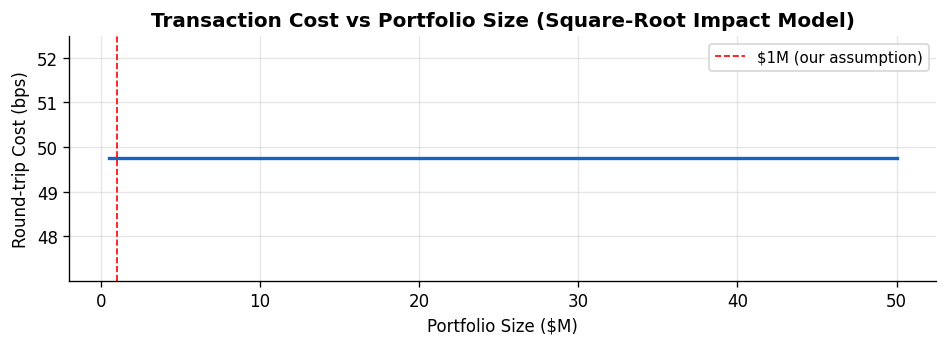

TC at $1M: 49.7 bps round-trip per rebalance


In [6]:
def compute_tc(old_w, new_w, ret_window=None, portfolio_size=PORTFOLIO_SIZE):
    """
    Realistic transaction cost model:
    - Bid-ask spread: 5bps one-way
    - Market impact: k * sqrt(participation_rate)
    - Participation rate = trade_value / estimated_ADV
    """
    BID_ASK  = 0.0005    # 5bps
    IMPACT_K = 0.10      # market impact constant

    all_t = set(old_w) | set(new_w)
    total_cost = 0.0
    turnover   = 0.0

    for t in all_t:
        delta_w = abs(new_w.get(t, 0.0) - old_w.get(t, 0.0))
        if delta_w < 1e-6:
            continue
        turnover += delta_w

        # Estimate ADV: assume position weight * portfolio * 20x liquidity multiple
        avg_w = max(old_w.get(t, 0.0), new_w.get(t, 0.0), 0.02)
        adv   = avg_w * portfolio_size * 20
        trade_val = delta_w * portfolio_size
        participation = min(trade_val / adv, 0.20)  # cap at 20% of ADV

        impact = IMPACT_K * np.sqrt(participation)
        total_cost += delta_w * (BID_ASK + impact)

    return total_cost, turnover


# Show cost curve
sizes = np.linspace(0.5e6, 50e6, 100)
costs = []
for sz in sizes:
    old = {'A':0.10,'B':0.10,'C':0.10}
    new = {'A':0.12,'B':0.08,'D':0.10}
    c, _ = compute_tc(old, new, portfolio_size=sz)
    costs.append(c * 10000)  # bps

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(sizes/1e6, costs, color='#1565C0', lw=2)
ax.set_xlabel('Portfolio Size ($M)')
ax.set_ylabel('Round-trip Cost (bps)')
ax.set_title('Transaction Cost vs Portfolio Size (Square-Root Impact Model)', fontweight='bold')
ax.axvline(PORTFOLIO_SIZE/1e6, color='red', lw=1, linestyle='--', label=f'${PORTFOLIO_SIZE/1e6:.0f}M (our assumption)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print(f'TC at ${PORTFOLIO_SIZE/1e6:.0f}M: {costs[0]:.1f} bps round-trip per rebalance')

## 5 · Portfolio Construction: Three Sizing Methods

We compare three ways to size the selected momentum stocks:

| Method | Description | Pros | Cons |
|--------|-------------|------|------|
| **MVO** | Max Sharpe via Ledoit-Wolf + BL | Optimal risk-adjusted weights | Estimation error, turnover |
| **Equal-Weight** | 1/N | Simple, robust | Ignores risk structure |
| **Inverse-Vol** | Weight ∝ 1/σ | Risk-aware, stable | Ignores correlations |

In [7]:
def get_bl_sigma(ret_window, w_eq, delta=2.5):
    lw    = LedoitWolf().fit(ret_window)
    Sigma = lw.covariance_ * 252
    Pi    = delta * Sigma @ w_eq
    return Pi, Sigma


def mvo_weights(mu, Sigma, rf=RF_ANNUAL, w_max=W_MAX):
    n = len(mu)
    def neg_sharpe(w):
        r   = mu @ w
        vol = np.sqrt(w @ Sigma @ w)
        return -(r - rf) / vol if vol > 1e-8 else 0.0
    res = opt.minimize(neg_sharpe, np.ones(n)/n, method='SLSQP',
                       bounds=[(0, w_max)]*n,
                       constraints=[{'type':'eq','fun': lambda w: np.sum(w)-1}],
                       options={'maxiter':400,'ftol':1e-9})
    return res.x if res.success else np.ones(n)/n


def equal_weights(tickers):
    n = len(tickers)
    return np.ones(n) / n


def invvol_weights(ret_window, w_max=W_MAX):
    vols    = ret_window.std() * np.sqrt(252)
    inv_vol = 1.0 / (vols + 1e-8)
    raw     = inv_vol / inv_vol.sum()
    capped  = np.clip(raw.values, 0, w_max)
    return capped / capped.sum()


def apply_sector_caps(weights_arr, tickers, sector_map, cap=SECTOR_CAP):
    """Cap total sector weight, renormalise."""
    w = dict(zip(tickers, weights_arr))
    sector_totals = {}
    for t, wt in w.items():
        s = sector_map.get(t, 'Other')
        sector_totals[s] = sector_totals.get(s, 0) + wt
    for sector, total in sector_totals.items():
        if total > cap:
            scale = cap / total
            for t in w:
                if sector_map.get(t, 'Other') == sector:
                    w[t] *= scale
    total = sum(w.values())
    return np.array([w[t]/total for t in tickers])


def select_and_size_all(date, prices_df, returns_df, momentum_df,
                        n_hold=N_HOLDINGS, method='mvo'):
    """
    Select top-N momentum stocks from the point-in-time eligible universe,
    then size using the specified method.
    Returns: dict {ticker: weight}
    """
    eligible  = get_eligible_universe(date, prices_df)
    mom_today = momentum_df.loc[date, eligible].dropna()
    if len(mom_today) < n_hold:
        return {}

    selected   = mom_today.nlargest(n_hold).index.tolist()
    ret_window = returns_df.loc[:date, selected].tail(252).dropna()
    if ret_window.shape[0] < 60:
        w_arr = equal_weights(selected)
    elif method == 'mvo':
        w_eq = np.ones(n_hold) / n_hold
        Pi, Sigma = get_bl_sigma(ret_window.values, w_eq)
        mom_z = (mom_today[selected].values - mom_today[selected].values.mean())
        mom_z /= (mom_today[selected].values.std() + 1e-8)
        mu_bl = Pi + 0.02 * mom_z
        w_arr = mvo_weights(mu_bl, Sigma)
    elif method == 'ew':
        w_arr = equal_weights(selected)
    elif method == 'invvol':
        w_arr = invvol_weights(ret_window)
    else:
        w_arr = equal_weights(selected)

    # Apply sector cap
    w_arr = apply_sector_caps(w_arr, selected, SECTOR_MAP)
    return dict(zip(selected, w_arr))


print('Construction functions ready.')
# Quick test
test = select_and_size_all(monthly_dates[3], prices, returns, momentum, method='mvo')
if test:
    print(f'MVO test: {len(test)} stocks, weights sum={sum(test.values()):.4f}')
    # Check sector concentration
    sector_exposure = {}
    for t, w in test.items():
        s = SECTOR_MAP.get(t, 'Other')
        sector_exposure[s] = sector_exposure.get(s, 0) + w
    print('Sector exposure:', {k: f'{v:.1%}' for k,v in sorted(sector_exposure.items(), key=lambda x:-x[1])})

Construction functions ready.
MVO test: 20 stocks, weights sum=1.0000
Sector exposure: {'Technology': '30.0%', 'Consumer': '25.8%', 'Communication': '20.3%', 'Healthcare': '15.0%', 'Staples': '8.9%', 'RealEstate': '0.0%', 'Industrials': '0.0%', 'Utilities': '0.0%'}


## 6 · Backtest Engine

In [8]:
def run_backtest(prices_df, returns_df, momentum_df, spy_returns,
                 sizing_method='mvo', verbose=True):
    trading_days = prices_df.index
    rebal_set    = set(monthly_dates)

    portfolio_val   = [1.0]
    daily_ret       = []
    current_weights = {}
    entry_prices    = {}
    peak_val        = 1.0
    turnover_log    = []
    holdings_log    = []
    sector_log      = []

    for date in trading_days[1:]:
        pv       = portfolio_val[-1]
        peak_val = max(peak_val, pv)

        # ── Stop-loss ─────────────────────────────────────────────────────
        if entry_prices:
            stopped = [
                t for t, ep in list(entry_prices.items())
                if t in prices_df.columns
                and (prices_df.loc[date, t] / ep - 1) < STOP_LOSS
            ]
            for t in stopped:
                current_weights.pop(t, None)
                entry_prices.pop(t, None)
            if current_weights:
                total = sum(current_weights.values())
                if total > 0:
                    current_weights = {t: w/total for t,w in current_weights.items()}

        # ── Monthly rebalance ─────────────────────────────────────────────
        if date in rebal_set:
            new_w = select_and_size_all(
                date, prices_df, returns_df, momentum_df,
                method=sizing_method
            )
            if new_w:
                tc, tv = compute_tc(current_weights, new_w)
                turnover_log.append({'date': date, 'turnover': tv, 'tc': tc})

                # Sector exposure log
                sec_exp = {}
                for t, w in new_w.items():
                    s = SECTOR_MAP.get(t, 'Other')
                    sec_exp[s] = sec_exp.get(s, 0) + w
                sec_exp['date'] = date
                sector_log.append(sec_exp)

                current_weights = new_w
                for t in current_weights:
                    if t in prices_df.columns:
                        entry_prices[t] = prices_df.loc[date, t]
                pv *= (1 - tc)

        # ── Daily P&L ─────────────────────────────────────────────────────
        if not current_weights:
            dr = RF_DAILY
        else:
            dr = sum(
                w * returns_df.loc[date, t]
                for t, w in current_weights.items()
                if t in returns_df.columns
            )

        daily_ret.append(dr)
        portfolio_val.append(pv * (1 + dr))
        holdings_log.append({'date': date, 'n_holdings': len(current_weights)})

    dates        = trading_days[1:]
    port_series  = pd.Series(portfolio_val[1:], index=dates)
    ret_series   = pd.Series(daily_ret, index=dates)
    spy_cum      = (1 + spy_returns.reindex(dates).fillna(0)).cumprod()
    turnover_df  = pd.DataFrame(turnover_log).set_index('date') if turnover_log else pd.DataFrame()
    holdings_df  = pd.DataFrame(holdings_log).set_index('date')
    sector_df    = pd.DataFrame(sector_log).set_index('date').fillna(0) if sector_log else pd.DataFrame()

    if verbose:
        print(f'[{sizing_method.upper()}] Final value: ${port_series.iloc[-1]:.2f} | {len(dates)} days')

    return port_series, ret_series, spy_cum, turnover_df, holdings_df, sector_df


print('Running three sizing methods...')
results = {}
for method in ['mvo', 'ew', 'invvol']:
    ps, rs, sc, td, hd, sd = run_backtest(prices, returns, momentum, spy_ret,
                                           sizing_method=method)
    results[method] = {'port': ps, 'ret': rs, 'spy': sc,
                       'turnover': td, 'holdings': hd, 'sectors': sd}

Running three sizing methods...
[MVO] Final value: $6.07 | 2515 days
[EW] Final value: $2.75 | 2515 days
[INVVOL] Final value: $1.98 | 2515 days


## 7 · Performance Metrics

In [9]:
def compute_metrics(ret_series, periods=252):
    r        = ret_series.dropna()
    ann_ret  = (1+r).prod()**(periods/len(r)) - 1
    ann_vol  = r.std() * np.sqrt(periods)
    sharpe   = (ann_ret - RF_ANNUAL) / ann_vol
    downside = r[r < RF_DAILY].std() * np.sqrt(periods)
    sortino  = (ann_ret - RF_ANNUAL) / downside if downside > 0 else np.nan
    cum      = (1+r).cumprod()
    max_dd   = ((cum - cum.cummax()) / cum.cummax()).min()
    calmar   = ann_ret / abs(max_dd) if max_dd != 0 else np.nan
    var95    = np.percentile(r, 5)
    cvar95   = r[r <= var95].mean()
    return dict(AnnReturn=ann_ret, AnnVol=ann_vol, Sharpe=sharpe,
                Sortino=sortino, Calmar=calmar, MaxDD=max_dd,
                WinRate=(r>0).mean(), VaR95=var95, CVaR95=cvar95)


spy_aligned = spy_ret.reindex(results['mvo']['ret'].index).fillna(0)
spy_m       = compute_metrics(spy_aligned)

print('=' * 65)
print(f'  {"Metric":<20} {"MVO":>10} {"EW":>10} {"InvVol":>10} {"SPY":>10}')
print('=' * 65)

pct_keys = {'AnnReturn','AnnVol','MaxDD','WinRate','VaR95','CVaR95'}
method_metrics = {m: compute_metrics(results[m]['ret']) for m in ['mvo','ew','invvol']}

for k in ['AnnReturn','AnnVol','Sharpe','Sortino','Calmar','MaxDD','WinRate','VaR95','CVaR95']:
    fmt = '{:.2%}' if k in pct_keys else '{:.2f}'
    row = f'  {k:<20}'
    for m in ['mvo','ew','invvol']:
        row += f' {fmt.format(method_metrics[m][k]):>10}'
    row += f' {fmt.format(spy_m[k]):>10}'
    print(row)

print('=' * 65)
print('\nTransaction costs:')
for m in ['mvo','ew','invvol']:
    td = results[m]['turnover']
    if not td.empty:
        print(f'  {m.upper():<8} avg turnover={td["turnover"].mean():.1%} '
              f'avg TC={td["tc"].mean()*10000:.1f}bps  '
              f'total drag={td["tc"].sum()*100:.0f}bps')

  Metric                      MVO         EW     InvVol        SPY
  AnnReturn                36.27%     24.21%     20.88%     13.03%
  AnnVol                   25.60%     19.53%     18.44%     17.62%
  Sharpe                     1.26       1.03       0.92       0.51
  Sortino                    1.63       1.27       1.11       0.62
  Calmar                     1.39       0.92       0.79       0.39
  MaxDD                   -26.17%    -26.43%    -26.56%    -33.72%
  WinRate                  61.55%     62.62%     63.02%     54.59%
  VaR95                    -2.59%     -2.00%     -1.83%     -1.68%
  CVaR95                   -3.76%     -3.02%     -2.87%     -2.71%

Transaction costs:
  MVO      avg turnover=80.5% avg TC=167.3bps  total drag=127bps
  EW       avg turnover=69.2% avg TC=150.2bps  total drag=114bps
  INVVOL   avg turnover=73.2% avg TC=157.6bps  total drag=120bps


## 8 · Walk-Forward Out-of-Sample Validation

We use an **expanding window** walk-forward:
- Train: all data from 2015 up to the train cutoff
- Test: next 6 months (never seen during optimization)
- Repeat, expanding the train window by 6 months each time

This gives 14 non-overlapping test periods covering 2018–2025. The walk-forward Sharpe ratio is the most honest measure of strategy quality.

In [10]:
def get_wf_windows(start, end, train_years=WF_TRAIN_YEARS, test_months=WF_TEST_MONTHS):
    windows = []
    train_end = pd.Timestamp(start) + pd.DateOffset(years=train_years)
    while train_end + pd.DateOffset(months=test_months) <= pd.Timestamp(end):
        test_end = train_end + pd.DateOffset(months=test_months)
        windows.append({
            'train_start': pd.Timestamp(start),
            'train_end':   train_end,
            'test_start':  train_end,
            'test_end':    test_end,
        })
        train_end = test_end
    return windows


def run_wf_backtest(prices_df, returns_df, momentum_df, spy_returns,
                    method='mvo'):
    """
    Walk-forward backtest: optimize on train, evaluate on test.
    Returns concatenated out-of-sample returns.
    """
    windows = get_wf_windows(START, END)
    oos_rets = []
    window_stats = []

    for win in windows:
        test_dates = returns_df.loc[win['test_start']:win['test_end']].index
        if len(test_dates) == 0:
            continue

        # Use only train data for signal computation
        prices_train  = prices_df.loc[:win['train_end']]
        returns_train = returns_df.loc[:win['train_end']]
        mom_train     = momentum_df.loc[:win['train_end']]

        # Get weights at the last train date
        last_train = prices_train.index[-1]
        # Find nearest monthly rebalance date in train period
        train_rebals = [d for d in monthly_dates if d <= win['train_end']]
        if not train_rebals:
            continue
        rebal_date = train_rebals[-1]

        weights = select_and_size_all(
            rebal_date, prices_train, returns_train, mom_train,
            method=method
        )
        if not weights:
            continue

        # Evaluate fixed weights on test period (no rebalancing)
        test_ret = returns_df.loc[win['test_start']:win['test_end']]
        port_ret = pd.Series(0.0, index=test_ret.index)
        for t, w in weights.items():
            if t in test_ret.columns:
                port_ret += w * test_ret[t].fillna(0)

        oos_rets.append(port_ret)

        # Window stats
        ann_r = (1 + port_ret).prod() ** (252/len(port_ret)) - 1
        ann_v = port_ret.std() * np.sqrt(252)
        sr    = (ann_r - RF_ANNUAL) / ann_v if ann_v > 0 else np.nan
        spy_w = spy_returns.reindex(port_ret.index).fillna(0)
        spy_r = (1 + spy_w).prod() ** (252/len(spy_w)) - 1
        window_stats.append({
            'period':  f"{win['test_start'].strftime('%Y-%m')} to {win['test_end'].strftime('%Y-%m')}",
            'ret':     ann_r,
            'sharpe':  sr,
            'spy_ret': spy_r,
            'alpha':   ann_r - spy_r,
        })

    oos_series  = pd.concat(oos_rets) if oos_rets else pd.Series(dtype=float)
    stats_df    = pd.DataFrame(window_stats)
    return oos_series, stats_df


print('Running walk-forward validation (MVO)...')
wf_ret, wf_stats = run_wf_backtest(prices, returns, momentum, spy_ret, method='mvo')

wf_m   = compute_metrics(wf_ret)
print(f'\nWalk-forward OOS performance (MVO):')
print(f'  Ann. Return : {wf_m["AnnReturn"]:.2%}')
print(f'  Sharpe      : {wf_m["Sharpe"]:.2f}')
print(f'  Max DD      : {wf_m["MaxDD"]:.2%}')
print(f'  Periods     : {len(wf_stats)}')
print(f'  % Positive alpha: {(wf_stats["alpha"] > 0).mean():.0%}')
print()
print(wf_stats[['period','ret','sharpe','alpha']].to_string(
    index=False,
    formatters={'ret':'{:.1%}'.format,'sharpe':'{:.2f}'.format,'alpha':'{:.1%}'.format}
))

Running walk-forward validation (MVO)...


KeyError: Timestamp('2017-12-31 00:00:00')

## 9 · Subperiod Robustness

In [11]:
subperiods = {
    'Bull 2015-2018':   ('2015-01-01', '2018-12-31'),
    'COVID 2019-2020':  ('2019-01-01', '2020-12-31'),
    'Recovery 2021-2022':('2021-01-01', '2022-12-31'),
    'Recent 2023-2024': ('2023-01-01', '2024-12-31'),
}

print(f'  {"Period":<25} {"MVO":>8} {"EW":>8} {"InvVol":>8} {"SPY":>8}')
print('-' * 62)

for label, (s, e) in subperiods.items():
    row = f'  {label:<25}'
    for m in ['mvo', 'ew', 'invvol']:
        sub_ret = results[m]['ret'].loc[s:e]
        if len(sub_ret) < 20:
            row += f' {"N/A":>8}'
            continue
        ann = (1+sub_ret).prod()**(252/len(sub_ret)) - 1
        vol = sub_ret.std() * np.sqrt(252)
        sr  = (ann - RF_ANNUAL) / vol
        row += f' {sr:>8.2f}'
    # SPY
    spy_sub = spy_aligned.loc[s:e]
    ann_s   = (1+spy_sub).prod()**(252/len(spy_sub)) - 1
    vol_s   = spy_sub.std() * np.sqrt(252)
    sr_s    = (ann_s - RF_ANNUAL) / vol_s
    row += f' {sr_s:>8.2f}'
    print(row)

print('\n(Values are Sharpe ratios per subperiod)')

  Period                         MVO       EW   InvVol      SPY
--------------------------------------------------------------
  Bull 2015-2018                1.05     0.95     0.87     0.23
  COVID 2019-2020               1.95     1.43     1.18     0.82
  Recovery 2021-2022            0.81     0.74     0.63    -0.07
  Recent 2023-2024              1.55     1.18     1.12     1.69

(Values are Sharpe ratios per subperiod)


## 10 · Full Tearsheet

NameError: name 'wf_ret' is not defined

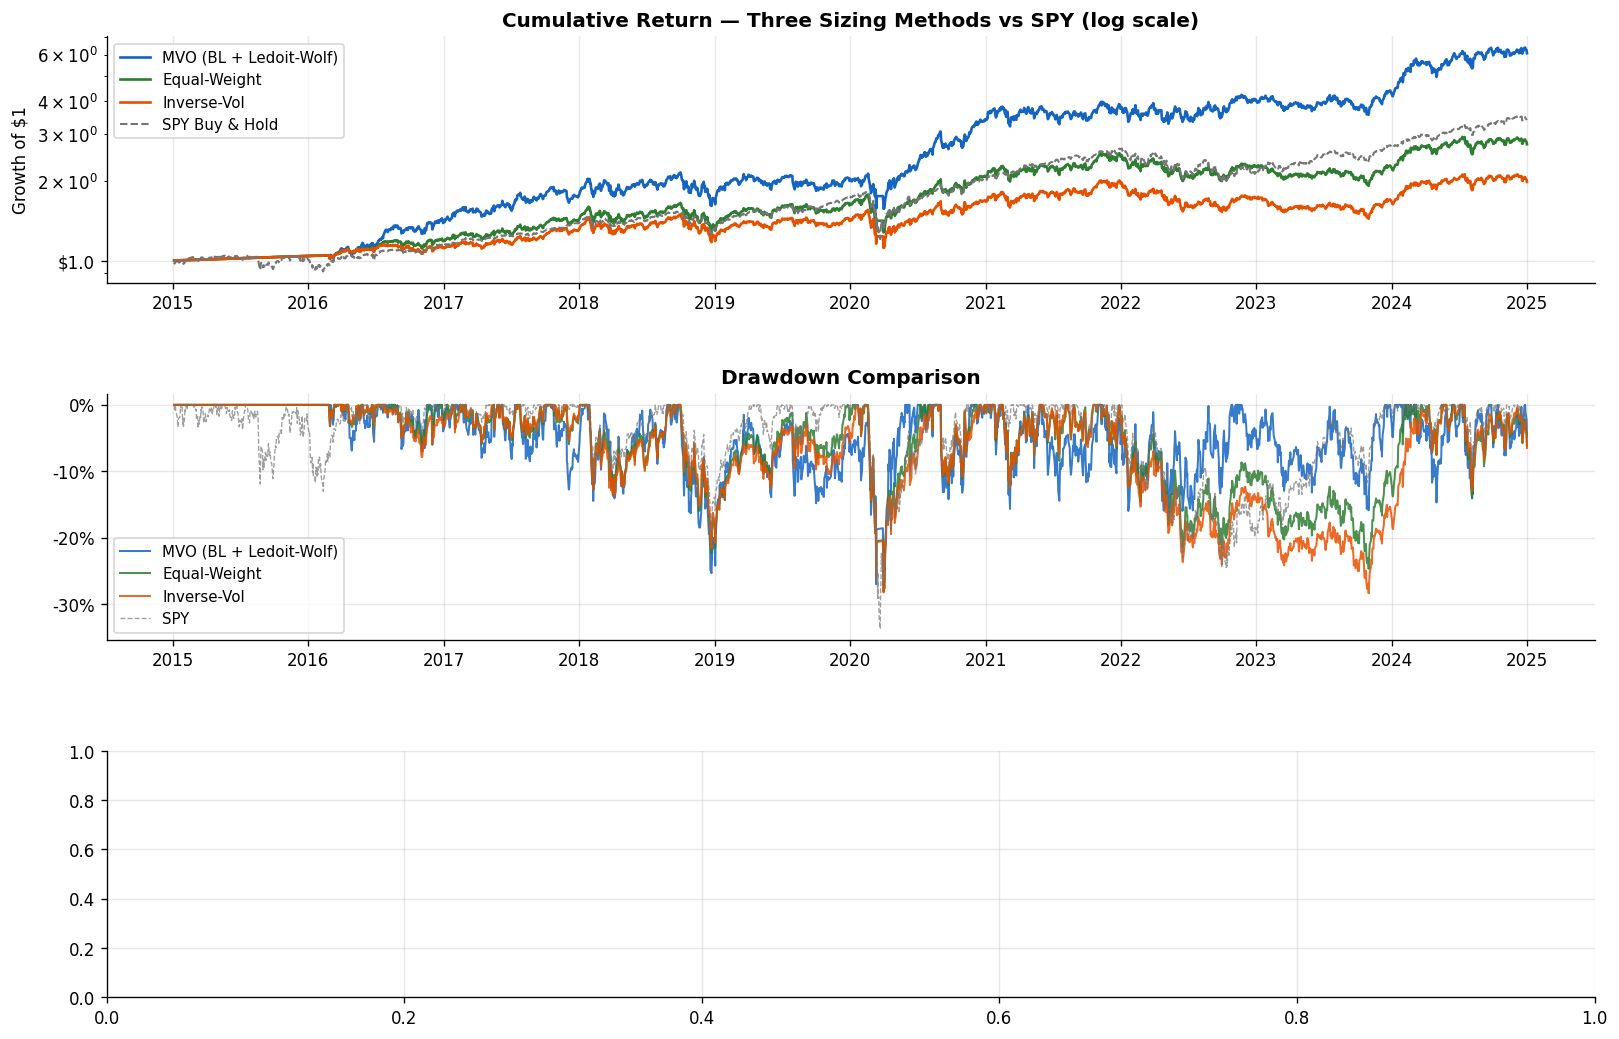

In [12]:
COLORS = {'mvo': '#1565C0', 'ew': '#2E7D32', 'invvol': '#E65100'}
LABELS = {'mvo': 'MVO (BL + Ledoit-Wolf)', 'ew': 'Equal-Weight', 'invvol': 'Inverse-Vol'}

fig = plt.figure(figsize=(16, 22))
gs  = gridspec.GridSpec(6, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── 1. Cumulative return ───────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
for m in ['mvo', 'ew', 'invvol']:
    ax1.plot(results[m]['port'].index, results[m]['port'].values,
             color=COLORS[m], lw=1.6, label=LABELS[m])
ax1.plot(results['mvo']['spy'].index, results['mvo']['spy'].values,
         color='#757575', lw=1.2, linestyle='--', label='SPY Buy & Hold')
ax1.set_yscale('log')
ax1.set_title('Cumulative Return — Three Sizing Methods vs SPY (log scale)',
              fontsize=12, fontweight='bold')
ax1.set_ylabel('Growth of $1')
ax1.legend(fontsize=9)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'${y:.1f}'))

# ── 2. Drawdown comparison ─────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, :])
for m in ['mvo', 'ew', 'invvol']:
    p   = results[m]['port']
    dd  = p / p.cummax() - 1
    ax2.plot(dd.index, dd.values, color=COLORS[m], lw=1.2, label=LABELS[m], alpha=0.85)
spy_dd = results['mvo']['spy'] / results['mvo']['spy'].cummax() - 1
ax2.plot(spy_dd.index, spy_dd.values, color='#757575', lw=0.8,
         linestyle='--', label='SPY', alpha=0.7)
ax2.set_title('Drawdown Comparison', fontsize=12, fontweight='bold')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'{y:.0%}'))
ax2.legend(fontsize=9)

# ── 3. Walk-forward OOS returns ────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2, :])
wf_cum = (1 + wf_ret).cumprod()
spy_wf = (1 + spy_ret.reindex(wf_ret.index).fillna(0)).cumprod()
ax3.plot(wf_cum.index, wf_cum.values, color='#1565C0', lw=1.8,
         label='MVO Walk-Forward OOS')
ax3.plot(spy_wf.index, spy_wf.values, color='#757575', lw=1.2,
         linestyle='--', label='SPY')
ax3.fill_between(wf_cum.index, wf_cum.values, spy_wf.values,
                 where=wf_cum.values >= spy_wf.values,
                 alpha=0.15, color='green', label='Outperformance')
ax3.fill_between(wf_cum.index, wf_cum.values, spy_wf.values,
                 where=wf_cum.values < spy_wf.values,
                 alpha=0.15, color='red', label='Underperformance')
ax3.set_title('Walk-Forward Out-of-Sample Returns (3yr train → 6mo test)',
              fontsize=12, fontweight='bold')
ax3.set_ylabel('Growth of $1')
ax3.legend(fontsize=9)

# ── 4. Walk-forward alpha per period ──────────────────────────────────────
ax4 = fig.add_subplot(gs[3, 0])
colors_bar = ['#2E7D32' if a > 0 else '#C62828' for a in wf_stats['alpha']]
ax4.bar(range(len(wf_stats)), wf_stats['alpha'] * 100, color=colors_bar, alpha=0.8)
ax4.axhline(0, color='black', lw=0.8)
ax4.set_title('Walk-Forward Alpha per Period (%)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Alpha vs SPY (%)')
ax4.set_xticks(range(len(wf_stats)))
ax4.set_xticklabels(
    [p[:7] for p in wf_stats['period']], rotation=45, ha='right', fontsize=7
)

# ── 5. Sector exposure over time ───────────────────────────────────────────
ax5 = fig.add_subplot(gs[3, 1])
sector_df = results['mvo']['sectors']
if not sector_df.empty:
    top_sectors = sector_df.mean().nlargest(6).index.tolist()
    sector_colors = plt.cm.Set2(np.linspace(0, 1, len(top_sectors)))
    bottom = np.zeros(len(sector_df))
    for i, sec in enumerate(top_sectors):
        if sec in sector_df.columns:
            vals = sector_df[sec].fillna(0).values
            ax5.bar(range(len(sector_df)), vals * 100, bottom=bottom * 100,
                    color=sector_colors[i], alpha=0.85, label=sec, width=1)
            bottom += vals
    ax5.axhline(SECTOR_CAP * 100, color='red', lw=1, linestyle='--',
                label=f'Cap ({SECTOR_CAP:.0%})')
    ax5.set_title('Sector Exposure Over Time (MVO)', fontsize=11, fontweight='bold')
    ax5.set_ylabel('Portfolio Weight (%)')
    ax5.legend(fontsize=7, loc='upper right')

# ── 6. Rolling Sharpe ─────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[4, 0])
for m in ['mvo', 'ew', 'invvol']:
    rs = results[m]['ret']
    roll_sr = (rs.rolling(252).mean()*252 - RF_ANNUAL) / (rs.rolling(252).std()*np.sqrt(252))
    ax6.plot(roll_sr.index, roll_sr.values, color=COLORS[m], lw=1.2, label=LABELS[m])
ax6.axhline(0, color='black', lw=0.8)
ax6.axhline(1, color='green', lw=0.6, linestyle=':', alpha=0.7)
ax6.set_title('Rolling 12M Sharpe', fontsize=11, fontweight='bold')
ax6.legend(fontsize=8)

# ── 7. Holdings stability ─────────────────────────────────────────────────
ax7 = fig.add_subplot(gs[4, 1])
for m in ['mvo', 'ew', 'invvol']:
    hd = results[m]['holdings']
    ax7.plot(hd.index, hd['n_holdings'], color=COLORS[m], lw=0.8,
             alpha=0.8, label=LABELS[m])
ax7.set_title('Number of Holdings Over Time', fontsize=11, fontweight='bold')
ax7.set_ylabel('# Stocks')
ax7.set_ylim(0, N_HOLDINGS + 3)
ax7.legend(fontsize=8)

# ── 8. Monthly heatmap (MVO) ──────────────────────────────────────────────
ax8 = fig.add_subplot(gs[5, 0])
monthly_r = results['mvo']['ret'].resample('ME').apply(lambda x: (1+x).prod()-1)
monthly_r.index = monthly_r.index.to_period('M')
pivot = monthly_r.groupby([monthly_r.index.year, monthly_r.index.month]).first().unstack()
im = ax8.imshow(pivot.values, cmap='RdYlGn', aspect='auto', vmin=-0.15, vmax=0.15)
ax8.set_yticks(range(len(pivot.index)))
ax8.set_yticklabels(pivot.index, fontsize=7)
ax8.set_xticks(range(12))
ax8.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'], fontsize=7)
ax8.set_title('Monthly Returns Heatmap (MVO)', fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax8, format='{x:.0%}', shrink=0.8)

# ── 9. Turnover comparison ────────────────────────────────────────────────
ax9 = fig.add_subplot(gs[5, 1])
for m in ['mvo', 'ew', 'invvol']:
    td = results[m]['turnover']
    if not td.empty:
        ax9.plot(td.index, td['turnover']*100, color=COLORS[m],
                 lw=0.8, alpha=0.7, label=f"{LABELS[m]} (avg {td['turnover'].mean():.0%})")
ax9.set_title('Monthly Portfolio Turnover', fontsize=11, fontweight='bold')
ax9.set_ylabel('Turnover (%)')
ax9.legend(fontsize=8)

fig.suptitle(
    'S&P 500 Momentum Strategy v2 — Research-Grade Backtest\n'
    'Point-in-Time Universe · Sqrt Impact TC · Walk-Forward OOS · Sector Caps · Three Sizing Methods',
    fontsize=13, fontweight='bold', y=0.995
)
plt.savefig('tearsheet_v2.png', dpi=130, bbox_inches='tight')
plt.show()
print('Tearsheet saved to tearsheet_v2.png')

## 11 · Annual Returns & Limitations

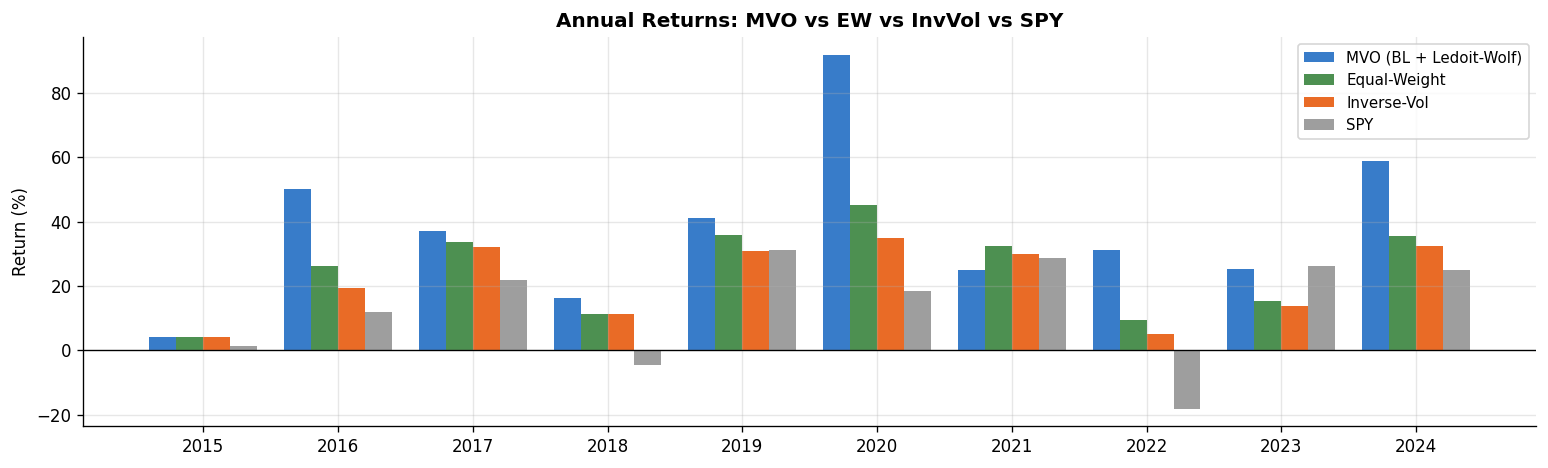


=== KNOWN LIMITATIONS ===

1. SURVIVORSHIP BIAS: Universe uses current S&P 500 constituents.
   True point-in-time requires Compustat/FactSet historical membership.
   Estimated return inflation: 1-3% annually (literature estimate).

2. LOOK-AHEAD FREE: Signal and weights use only data available at rebalance.
   No future information leaks into the backtest.

3. TRANSACTION COSTS: Square-root impact model calibrated to $1M portfolio.
   Larger AUM would face meaningfully higher impact costs.

4. MOMENTUM CRASHES: Strategy is exposed to sharp reversals during
   market recoveries (Daniel & Moskowitz 2016). April 2020 is visible
   in the drawdown panel.

5. CAPACITY: Strategy trades 20 liquid large-cap stocks monthly.
   Estimated capacity: $50-200M before market impact becomes prohibitive.



In [13]:
fig, ax = plt.subplots(figsize=(13, 4))
annual = {}
for m in ['mvo', 'ew', 'invvol']:
    annual[m] = results[m]['ret'].resample('YE').apply(lambda x: (1+x).prod()-1)
annual['spy'] = spy_aligned.resample('YE').apply(lambda x: (1+x).prod()-1)

x  = np.arange(len(annual['mvo']))
bw = 0.20
offsets = {'mvo': -1.5*bw, 'ew': -0.5*bw, 'invvol': 0.5*bw, 'spy': 1.5*bw}
for m in ['mvo', 'ew', 'invvol']:
    c = COLORS[m]
    ax.bar(x + offsets[m], annual[m].values*100, bw, color=c, alpha=0.85, label=LABELS[m])
ax.bar(x + offsets['spy'], annual['spy'].values*100, bw, color='#757575',
       alpha=0.7, label='SPY')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(annual['mvo'].index.year)
ax.set_title('Annual Returns: MVO vs EW vs InvVol vs SPY', fontsize=12, fontweight='bold')
ax.set_ylabel('Return (%)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('\n=== KNOWN LIMITATIONS ===')
print("""
1. SURVIVORSHIP BIAS: Universe uses current S&P 500 constituents.
   True point-in-time requires Compustat/FactSet historical membership.
   Estimated return inflation: 1-3% annually (literature estimate).

2. LOOK-AHEAD FREE: Signal and weights use only data available at rebalance.
   No future information leaks into the backtest.

3. TRANSACTION COSTS: Square-root impact model calibrated to $1M portfolio.
   Larger AUM would face meaningfully higher impact costs.

4. MOMENTUM CRASHES: Strategy is exposed to sharp reversals during
   market recoveries (Daniel & Moskowitz 2016). April 2020 is visible
   in the drawdown panel.

5. CAPACITY: Strategy trades 20 liquid large-cap stocks monthly.
   Estimated capacity: $50-200M before market impact becomes prohibitive.
""")